# First Classification 🐥🐥

0. Import usual libraries

In [33]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings(
    "ignore", category=DeprecationWarning
)  # to avoid deprecation warnings

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

# setting Jedha color palette as default
pio.templates["jedha"] = go.layout.Template(
    layout_colorway=[
        "#4B9AC7",
        "#4BE8E0",
        "#9DD4F3",
        "#97FBF6",
        "#2A7FAF",
        "#23B1AB",
        "#0E3449",
        "#015955",
    ]
)
pio.templates.default = "jedha"
pio.renderers.default = "svg"  # to be replaced by "iframe" if working on JULIE

1. Download the following data using this link : ```https://full-stack-bigdata-datasets.s3.eu-west-3.amazonaws.com/Machine+Learning+Supervis%C3%A9/R%C3%A9gression+logistique+Cross+validation/Datasets/ex2data1.txt``` and put it into a DataFrame

Pay attention to the header of the DataFrame, there's something annoying with it! Look at the documentation of `pd.read_csv()` to find a way of solving the problem 🤓

In [34]:
# Import dataset
print("Loading dataset...")
dataset = pd.read_csv("https://full-stack-bigdata-datasets.s3.eu-west-3.amazonaws.com/Machine+Learning+Supervis%C3%A9/R%C3%A9gression+logistique+Cross+validation/Datasets/ex2data1.txt", header=None)
print("...Done.")
print()

Loading dataset...
...Done.



In [35]:
print("Shape of dataset:", dataset.shape)
dataset.head()

Shape of dataset: (100, 3)


,0,1,2
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0
3,60.182599,86.308552,1
4,79.032736,75.344376,1


2. Rename the columns using the following names : 

"Col_1" / "Col_2" / "Target"

In [36]:
dataset = dataset.rename(columns={0: "Col_1", 1: "Col_2", 2: "Target"})
dataset

,Col_1,Col_2,Target
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0
3,60.182599,86.308552,1
4,79.032736,75.344376,1
...,...,...,...
95,83.489163,48.380286,1
96,42.261701,87.103851,1
97,99.315009,68.775409,1
98,55.340018,64.931938,1


3. Visualize the data as a scatter plot where the two different classes are displayed with different colors.

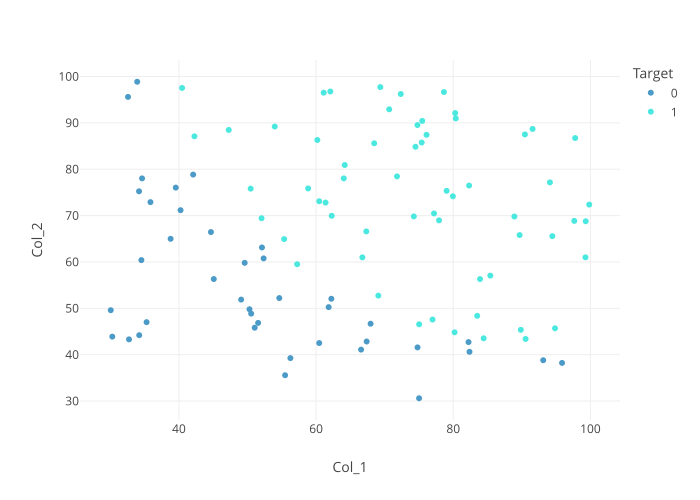

In [79]:
fig = px.scatter(dataset, x = 'Col_1', y = 'Col_2', color = dataset['Target'].astype('str'), labels = {'color': 'Target'})
fig.show()

4. Separate X and y into two different objects.

In [38]:
# Separate target variable Y from features X
print("Separating labels from features...")
features_list = ["Col_1", "Col_2"]
target_variable = "Target"

X = dataset.loc[:, features_list]
Y = dataset.loc[:, target_variable]

print("...Done.")
print()

print("Y : ")
print(Y.head())
print()
print("X :")
print(X.head())

Separating labels from features...
...Done.

Y : 
0    0
1    0
2    0
3    1
4    1
Name: Target, dtype: int64

X :
       Col_1      Col_2
0  34.623660  78.024693
1  30.286711  43.894998
2  35.847409  72.902198
3  60.182599  86.308552
4  79.032736  75.344376


5. Split the data into a train set and a test set

In [39]:
# Divide dataset Train set & Test set
print("Dividing into train and test sets...")
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)
print("...Done.")
print()

Dividing into train and test sets...
...Done.



6. Do you think that the two variables "Col_1" and "Col_2" would be good predictors of the target?

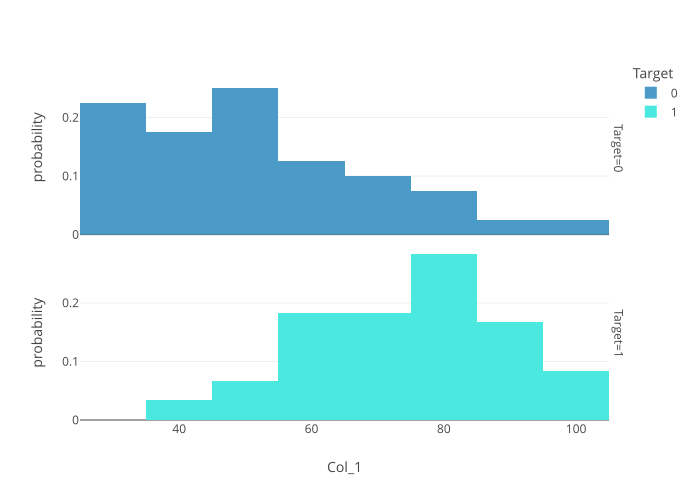

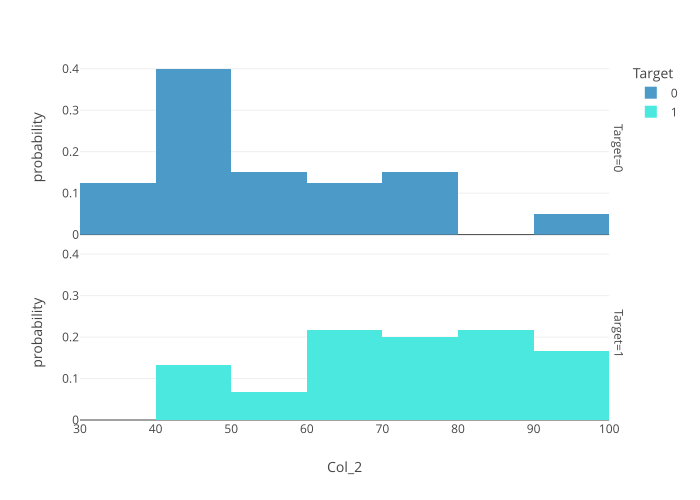

In [40]:
# Univariate analysis
# Distribution of each numeric variable
for f in features_list:
    fig = px.histogram(dataset, f, color=target_variable, facet_row=target_variable, histnorm="probability")
    fig.show()

7. Analyze the explanatory variables, what preprocessings are necessary? Make the preprocessings.

In [41]:
dataset.describe()

,Col_1,Col_2,Target
count,100.000000,100.000000,100.000000
mean,65.644274,66.221998,0.600000
std,19.458222,18.582783,0.492366
min,30.058822,30.603263,0.000000
25%,50.919511,48.179205,0.000000
50%,67.032988,67.682381,1.000000
75%,80.212529,79.360605,1.000000
max,99.827858,98.869436,1.000000


Some good news:
* There are no missing values in this dataset --> no imputation needed
* Although we're dealing with a classification problem, the _Target_ is already encoded as 0s and 1s, so we don't need to use the LabelEncoder
* All the features (_Col1_ and _Col2_) are numeric, so we just want to apply a StandardScaler to the whole array X

In [ ]:
print("Performing preprocessing on train set...")
print(X_train.head())
print()
preprocessor = StandardScaler()
X_train = preprocessor.fit_transform(X_train)
print("...Done!")
print(X_train[0:5, :])  # X_train is now a numpy array
print()

print("Performing preprocessing on test set...")
print(X_test.head())
print()
X_test = preprocessor.transform(X_test)
print("...Done!")
print(X_test[0:5, :])  # X_train is now a numpy array
print()

Performing preprocessing on train set...
        Col_1      Col_2
43  82.368754  40.618255
62  56.253817  39.261473
3   60.182599  86.308552
71  64.039320  78.031688
45  62.222676  52.060992

...Done!
[[ 0.80451601 -1.39362426]
 [-0.50529573 -1.46548914]
 [-0.3082451   1.02645931]
 [-0.11480873  0.58805764]
 [-0.20592373 -0.78753542]]

Performing preprocessing on test set...
        Col_1      Col_2
26  80.190181  44.821629
86  42.075455  78.844786
2   35.847409  72.902198
55  49.586677  59.808951
75  99.827858  72.369252

...Done!
[[ 0.69524825 -1.17098365]
 [-1.21642081  0.6311251 ]
 [-1.52879253  0.31636331]
 [-0.83969052 -0.37714832]
 [ 1.68018881  0.28813469]]



8. Use the LogisticRegression function from sklearn in order to create a model instance and train it.

In [ ]:
classifier = LogisticRegression()
classifier.fit(X_train, Y_train)

LogisticRegression()

9. What's the accuracy on the train set ? and on the test set ?

Find a way of evaluating the scores without explicitely computing the model's predictions.

In [ ]:
# Y_train_pred = classifier.predict(X_train)
# Y_test_pred = classifier.predict(X_test)

print("Train accuracy: ", classifier.score(X_train, Y_train))
print("Test accuracy:", classifier.score(X_test, Y_test))

Train accuracy:  0.9125
Test accuracy: 0.8


10. What's the average score with a cross-validation using K=10, what's the score's standard deviation?

In [ ]:
scores = cross_val_score(classifier, X_train, Y_train, cv=10)
print("Cross_validated accuracy:", scores.mean())
print("Standard deviation:", scores.std())

Cross_validated accuracy: 0.9
Standard deviation: 0.12247448713915891


11. Is the model underfitting/overfitting?

12. Create objects containing the model's predictions on the train/test sets, as well as the estimated probabilities

In [46]:
print("Predictions on training set...")
Y_train_pred = classifier.predict(X_train)
print("...Done.")
print(Y_train_pred)
print()
# It's also possible to get the probabilities estimated by the model:
print("Probabilities on training set...")
Y_train_proba = classifier.predict_proba(X_train)
print("...Done.")
print(Y_train_proba)
print()

Predictions on training set...
...Done.
[0 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 1 0 1 1 0 1 0 0 1 1 0 0 0 1 0
 0 0 1 1 1 1 1 0 1 0 1 0 0 0 0 1 1 0 1 0 1 1 1 1 1 1 1 0 0 1 1 1 0 1 1 1 0
 1 1 0 0 1 0]

Probabilities on training set...
...Done.
[[0.58214783 0.41785217]
 [0.96142109 0.03857891]
 [0.08526035 0.91473965]
 [0.1340051  0.8659949 ]
 [0.76533194 0.23466806]
 [0.02361479 0.97638521]
 [0.02679301 0.97320699]
 [0.01398557 0.98601443]
 [0.27881802 0.72118198]
 [0.22121569 0.77878431]
 [0.01972988 0.98027012]
 [0.02750519 0.97249481]
 [0.00726499 0.99273501]
 [0.00596064 0.99403936]
 [0.02456975 0.97543025]
 [0.35578778 0.64421222]
 [0.01479397 0.98520603]
 [0.01241681 0.98758319]
 [0.99201351 0.00798649]
 [0.25303914 0.74696086]
 [0.99561488 0.00438512]
 [0.98962221 0.01037779]
 [0.02463776 0.97536224]
 [0.94648437 0.05351563]
 [0.04147043 0.95852957]
 [0.1149204  0.8850796 ]
 [0.76404557 0.23595443]
 [0.17428432 0.82571568]
 [0.73501692 0.26498308]
 [0.92475174 0.07524826]
 [0

In [47]:
print("Predictions on test set...")
Y_test_pred = classifier.predict(X_test)
print("...Done.")
print(Y_test_pred[0:5])
print()
# It's also possible to get the probabilities estimated by the model:
print("Probabilities on test set...")
Y_test_proba = classifier.predict_proba(X_test)
print("...Done.")
print(Y_test_proba[0:5])
print()

Predictions on test set...
...Done.
[0 0 0 0 1]

Probabilities on test set...
...Done.
[[0.52427805 0.47572195]
 [0.58531246 0.41468754]
 [0.83899565 0.16100435]
 [0.83926827 0.16073173]
 [0.00675475 0.99324525]]



13. Display the confusion matrix derived from the predictions performed by your model on the training data, do the same on your test data. What do you think of your model's performance, do you think it would generalize well on unknown data?

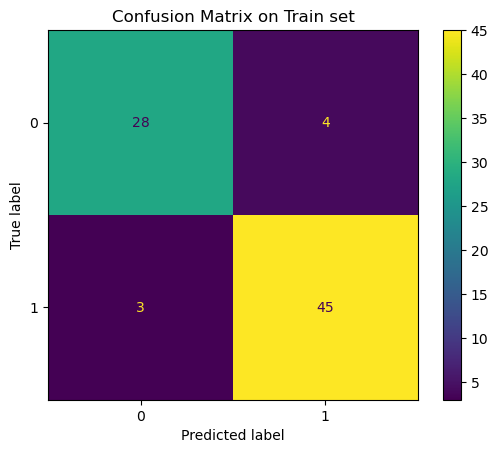

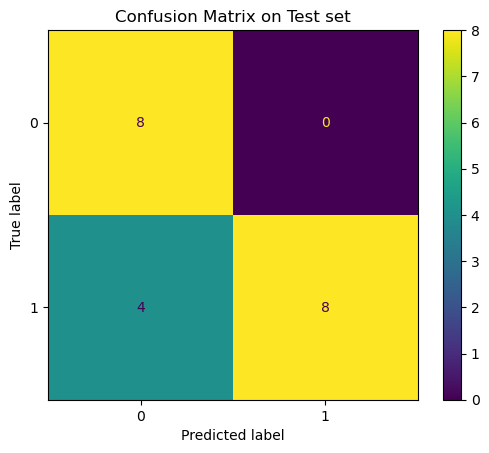

In [48]:
# Visualize confusion matrices
_, ax = plt.subplots()  # Get subplot from matplotlib
ax.set(
    title="Confusion Matrix on Train set"
)  # Set a title that we will add into ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(
    classifier, X_train, Y_train, ax=ax
)  # ConfusionMatrixDisplay from sklearn
plt.show()

_, ax = plt.subplots()  # Get subplot from matplotlib
ax.set(
    title="Confusion Matrix on Test set"
)  # Set a title that we will add into ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(
    classifier, X_test, Y_test, ax=ax
)  # ConfusionMatrixDisplay from sklearn
plt.show()

**From the questions above, we can deduce that the generalized performances are very good ! Indeed, the test accuracy is comparable to the train accuracy and we can see in the confusion matrix that the prediction errors are very rare 🥳🥳**

14. Produce the ROC curve for the train set and the test set

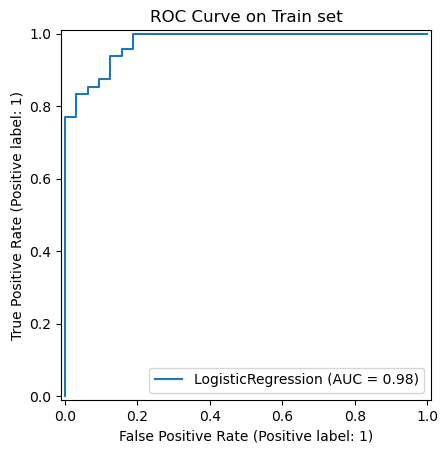

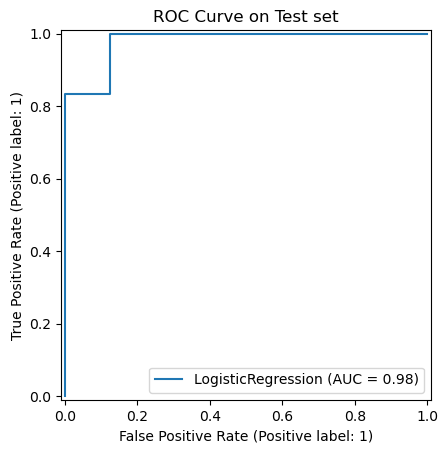

In [49]:
# Visualize ROC curves
_, ax = plt.subplots()  # Get subplot from matplotlib
ax.set(title="ROC Curve on Train set")  # Set a title that we will add into ConfusionMatrixDisplay
RocCurveDisplay.from_estimator(classifier, X_train, Y_train, ax=ax)  # RocCurveDisplay from sklearn
plt.show()

_, ax = plt.subplots()  # Get subplot from matplotlib
ax.set(title="ROC Curve on Test set")  # Set a title that we will add into ConfusionMatrixDisplay
RocCurveDisplay.from_estimator(classifier, X_test, Y_test, ax=ax)  # RocCurveDisplay from sklearn
plt.show()

**The area under the curves is quite close to 1. This means that the model is robust as it does not depend on the choice of the threshold used in the logistic regression.**

15. Create a DataFrame named predictions_df_train that contains the following values on train set:
* explanatory variables "Col_1" and "Col_2"
* the target variable Y
* the predictions Y_pred 
* the estimated probabilites from the classifier. 

Sort the values according to the probabilities (in ascending order).

In [74]:
predictions_df_train = pd.DataFrame(X_train, columns = ['Col_1', 'Col_2'])
predictions_df_train["Y"] = Y_train.tolist()
predictions_df_train["Y_pred"] = Y_train_pred.tolist()
predictions_df_train["Proba"] = Y_train_proba[:,1]
predictions_df_train = predictions_df_train.sort_values(by="Proba")
predictions_df_train.head()

,Col_1,Col_2,Y,Y_pred,Proba
20,-1.807693,-1.220065,0,0,0.004385
69,-1.685508,-1.251200,0,0,0.005300
38,-1.610814,-1.203405,0,0,0.006831
18,-1.819123,-0.918259,0,0,0.007986
21,-1.556945,-1.054515,0,0,0.010378


16. Plot the probabilities as a function of the variables "Col_1" and "Col_2". Change the marker color according to the values of "Y_pred".

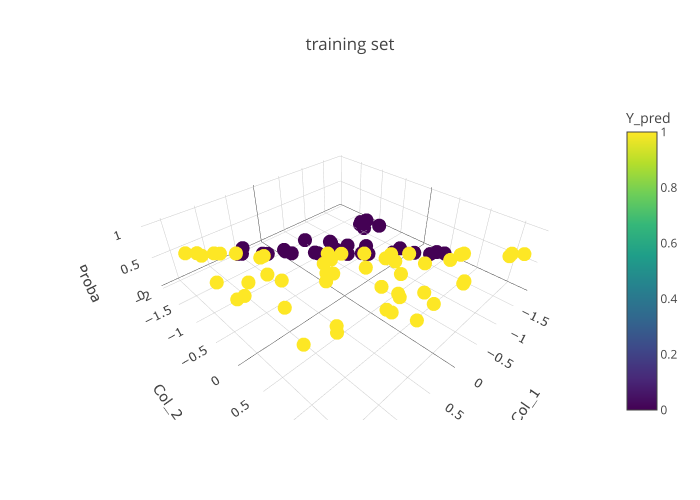

In [75]:
fig = px.scatter_3d(predictions_df_train, x = 'Col_1', y = 'Col_2', z = 'Proba', title = "training set", color = 'Y_pred')
fig.show()

17. Use the library mlxtend to plot the decision boundary of the model. You might need to install it before : 
```python
!pip install mlxtend
```
This documentation page might help you 😉 : http://rasbt.github.io/mlxtend/api_subpackages/mlxtend.plotting/

In [77]:
!pip install mlxtend


   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 44.5 MB/s eta 0:00:00


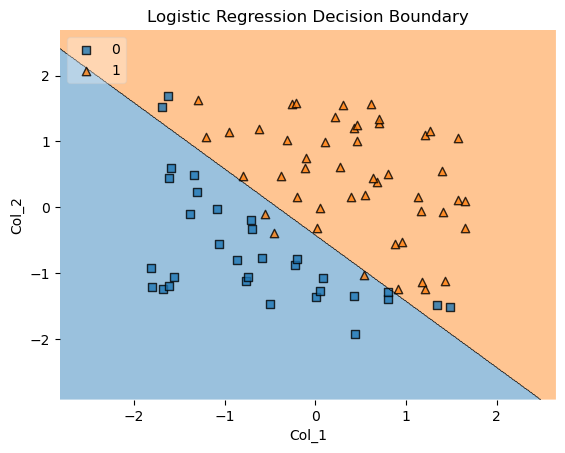

In [78]:
from mlxtend.plotting import plot_decision_regions


X = predictions_df_train.iloc[:,:2].values
Y = predictions_df_train.loc[:,"Y"].values

# Plotting decision regions
plot_decision_regions(X, Y, clf=classifier, legend=2)

# Adding axes annotations
plt.xlabel('Col_1')
plt.ylabel('Col_2')
plt.title('Logistic Regression Decision Boundary')
plt.show()
